notes for this PICASO4 hybrid notebook

- same purpose as `timestep/2_9_2026/run_roadrunner_phase_60_egp_g100_hybrid.ipynb`
- run from the `picaso4` conda environment / `Python (picaso4)` kernel
- keep the RoadRunner reflected-light framework, but force the notebook phase to 60 degrees
- replace the thermal side with the EGP `g100` `IRflux` files
- use the full local copy of SLGRID + EGP data under `aurora/science_inputs`
- still loop over the RoadRunner reflected-light grid for `logg`, `R_p_Rj`, `a_AU`, and the notebook phase override


# ROADRUNNER — Roman CGI 10% Threshold Test — Phase 60° — Hybrid EGP g100 Thermal — PICASO4

This notebook is the PICASO4-ready version of the original phase-60 RoadRunner/EGP workflow.

Hybrid setup:
- `PICASO 4` computes the reflected-light spectrum for each RoadRunner case at `PHASE_DEG = [60.0]`
- `EGP Grid for Daniel` provides the thermal spectrum from `SLGRID_T{T}_g100_..._IRflux.txt`
- the thermal file is matched by temperature only and injected into the band-metric calculation
- all SLGRID PT/cloud and EGP IRflux inputs are local to this Aurora repo


In [1]:
# -- Imports and PICASO4-local path setup ---------------------------
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', category=RuntimeWarning)

import pandas as pd
from IPython.display import display

# Find the aurora repo whether Jupyter starts in the repo root,
# this notebook folder, or a parent directory.
SEARCH_ROOTS = [Path.cwd(), *Path.cwd().parents]
SEARCH_ROOTS.append(Path('/Users/xin/Documents/Documents/College/aurora'))

for candidate in SEARCH_ROOTS:
    if (candidate / 'roadrunner_egp' / 'roadrunner').exists():
        REPO_ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError('Could not locate aurora/roadrunner_egp/roadrunner.')

ROADRUNNER_ROOT = REPO_ROOT / 'roadrunner_egp'
SCIENCE_INPUTS = REPO_ROOT / 'science_inputs'
RESULTS_DIR = ROADRUNNER_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Force this notebook to use the Aurora data, regardless of
# whatever shell/Jupyter environment variables were active before launch.
os.environ['ROADRUNNER_SCIENCE_INPUTS'] = str(SCIENCE_INPUTS)
os.environ['picaso_refdata'] = str(REPO_ROOT / 'picaso4_reference')
os.environ['PYSYN_CDBS'] = str(REPO_ROOT / 'picaso4_reference' / 'stellar_grids')
os.environ['SLGRID_BASE_DIR'] = str(SCIENCE_INPUTS / 'slgrid')
os.environ['SLGRID_PT_DIR'] = str(SCIENCE_INPUTS / 'slgrid' / 'climate')
os.environ['SLGRID_CLD_DIR'] = str(SCIENCE_INPUTS / 'slgrid' / 'clouds')
os.environ['EGP_IRFLUX_DIR'] = str(SCIENCE_INPUTS / 'egp' / 'irflux')

if str(ROADRUNNER_ROOT) not in sys.path:
    sys.path.insert(0, str(ROADRUNNER_ROOT))

# Drop any previously imported RoadRunner modules so the env vars above win
# if this notebook is re-run inside a live kernel.
for module_name in list(sys.modules):
    if (
        module_name == 'roadrunner'
        or module_name.startswith('roadrunner.')
        or module_name == 'workflows.hybrid_reflected_picaso_thermal_egp'
    ):
        del sys.modules[module_name]

from workflows.hybrid_reflected_picaso_thermal_egp import (
    SystemParams,
    available_hybrid_temperatures,
    egp_inventory,
    evaluate_hybrid_case,
    run_hybrid_grid_parallel,
    thermal_source_summary,
)
from roadrunner.config import (
    HAVE_PICASO,
    CGI_BANDS,
    LAM_GRID,
    REFLECT_THRESHOLD,
    LOGGS_CGS,
    R_PLANETS_Rj,
    SEMI_MAJOR_AU,
    PHASE_DEG as ROADRUNNER_DEFAULT_PHASE_DEG,
    SLGRID_PT_DIR,
    SLGRID_CLD_DIR,
    EGP_IRFLUX_DIR,
)
from roadrunner.bands import (
    normalize_band_names,
    select_bands,
    wavelength_grid_for_bands,
)
from roadrunner.plotting import (
    plot_summary_histogram,
    plot_summary_heatmaps,
)

PHASE_DEG = [60.0]

print(f'Repo root: {REPO_ROOT}')
print(f'PICASO available: {HAVE_PICASO}')
print(f'picaso_refdata: {os.environ["picaso_refdata"]}')
print(f'PYSYN_CDBS: {os.environ["PYSYN_CDBS"]}')
print(f'SLGRID climate: {SLGRID_PT_DIR}')
print(f'SLGRID clouds: {SLGRID_CLD_DIR}')
print(f'EGP IRflux: {EGP_IRFLUX_DIR}')
print(f'Threshold: {REFLECT_THRESHOLD*100}%')
print(f'RoadRunner default phase: {ROADRUNNER_DEFAULT_PHASE_DEG}')
print(f'Notebook phase override: {PHASE_DEG}')
print(f'Wavelength grid: {LAM_GRID.min():.2f}-{LAM_GRID.max():.2f} um  ({len(LAM_GRID)} pts)')
print(f'CGI bands: {list(CGI_BANDS.keys())}')


Repo root: /Users/dhuang/Documents/daniel/research/aurora
PICASO available: True
picaso_refdata: /Users/dhuang/Documents/daniel/research/aurora/picaso4_reference
PYSYN_CDBS: /Users/dhuang/Documents/daniel/research/aurora/picaso4_reference/stellar_grids
SLGRID climate: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/slgrid/climate
SLGRID clouds: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/slgrid/clouds
EGP IRflux: /Users/dhuang/Documents/daniel/research/aurora/science_inputs/egp/irflux
Threshold: 10.0%
RoadRunner default phase: [0.0]
Notebook phase override: [60.0]
Wavelength grid: 0.30-1.00 um  (1200 pts)
CGI bands: ['CGI-1', 'CGI-2', 'CGI-3', 'CGI-4']


---
## Local Data Coverage

This checks that the notebook is using the full local data copy in `aurora/science_inputs`, not the old `timestep` folders.


In [2]:
pt_count = sum(1 for _ in Path(SLGRID_PT_DIR).glob('*'))
cld_count = sum(1 for _ in Path(SLGRID_CLD_DIR).glob('*'))
egp_count = sum(1 for _ in Path(EGP_IRFLUX_DIR).glob('*_IRflux.txt'))

print(f'SLGRID PT files: {pt_count:,}')
print(f'SLGRID cloud files: {cld_count:,}')
print(f'EGP IRflux files: {egp_count:,}')

if pt_count < 10000 or cld_count < 10000:
    raise RuntimeError('Expected the full local SLGRID copy. Check science_inputs/slgrid/.')
if egp_count < 60:
    raise RuntimeError('Expected the copied EGP IRflux grid. Check science_inputs/egp/irflux/.')


SLGRID PT files: 11,602
SLGRID cloud files: 12,590
EGP IRflux files: 12,248


---
## EGP g100 Coverage

The reflected-light side is limited to the temperatures that exist in both the local SLGRID inventory and the EGP `g100` thermal inventory.


In [3]:
EGP_GRAVITY_CODE = '100'

# Choose which Roman CGI band(s) to run.
# Examples: 'CGI-1', 1, 'band one', ['CGI-1', 'CGI-2'], or 'all'.
SELECTED_BANDS = 'all'
SELECTED_BAND_NAMES = normalize_band_names(SELECTED_BANDS)
SELECTED_BAND_FILTERS = select_bands(SELECTED_BAND_NAMES, LAM_GRID)
RUN_LAM_GRID = wavelength_grid_for_bands(SELECTED_BAND_NAMES, LAM_GRID)

if SELECTED_BAND_NAMES == list(CGI_BANDS):
    OUTPUT_BAND_TAG = 'all'
else:
    OUTPUT_BAND_TAG = '_'.join(name.lower().replace('-', '') for name in SELECTED_BAND_NAMES)

GRID_TEFFS_K = available_hybrid_temperatures(gravity_code=EGP_GRAVITY_CODE)
EGP_TABLE = thermal_source_summary(gravity_code=EGP_GRAVITY_CODE)

print('Hybrid temperatures used in this notebook:', GRID_TEFFS_K)
print('Selected CGI bands:', SELECTED_BAND_NAMES)
print(f'Run wavelength grid: {RUN_LAM_GRID.min():.3f}-{RUN_LAM_GRID.max():.3f} um ({len(RUN_LAM_GRID)} pts)')
display(EGP_TABLE)


Hybrid temperatures used in this notebook: [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800]
Selected CGI bands: ['CGI-1', 'CGI-2', 'CGI-3', 'CGI-4']
Run wavelength grid: 0.300-1.000 um (1200 pts)


,temperature_k,gravity_code,filename,used_in_hybrid_grid
0,300,100,SLGRID_T300_g100_m+000_CO050_fsed0.3_frac25_IR...,False
1,300,100,SLGRID_T300_g100_m-050_CO050_fsed0.3_frac10_IR...,False
2,300,100,SLGRID_T300_g100_m+100_CO200_fsed8_frac75_IRfl...,False
3,300,100,SLGRID_T300_g100_m+100_CO200_fsed8_frac50_IRfl...,False
4,300,100,SLGRID_T300_g100_m+100_CO200_fsed8_frac25_IRfl...,False
...,...,...,...,...
2172,3000,100,SLGRID_T3000_g100_m+050_CO100_NC_IRflux.txt,False
2173,3000,100,SLGRID_T3000_g100_m+050_CO050_NC_IRflux.txt,False
2174,3000,100,SLGRID_T3000_g100_m+000_CO200_NC_IRflux.txt,False
2175,3000,100,SLGRID_T3000_g100_m+000_CO050_NC_IRflux.txt,False


---
## Validation Case

One optional hybrid case to confirm the spectra and band metrics before launching or refreshing the full grid.


=== VALIDATION CASE ===
Teff=1000K, logg=4, Rp=1.0 Rj, a=10 AU, alpha=60 deg, thermal=EGP g100, bands=['CGI-1', 'CGI-2', 'CGI-3', 'CGI-4']
✓ Using SLGRID PT:  SLGRID_T1000_g100_m+000_CO100_fsed3_full.pt
✓ Using SLGRID CLD: SLGRID_T1000_g100_m+000_CO100_fsed3_picaso.cld
✓ Using EGP thermal file: SLGRID_T1000_g100_m+000_CO050_NC_IRflux.txt
✓ Reflected spectrum matches stellar BB (T_fit=5778K vs T★=5778.0K)


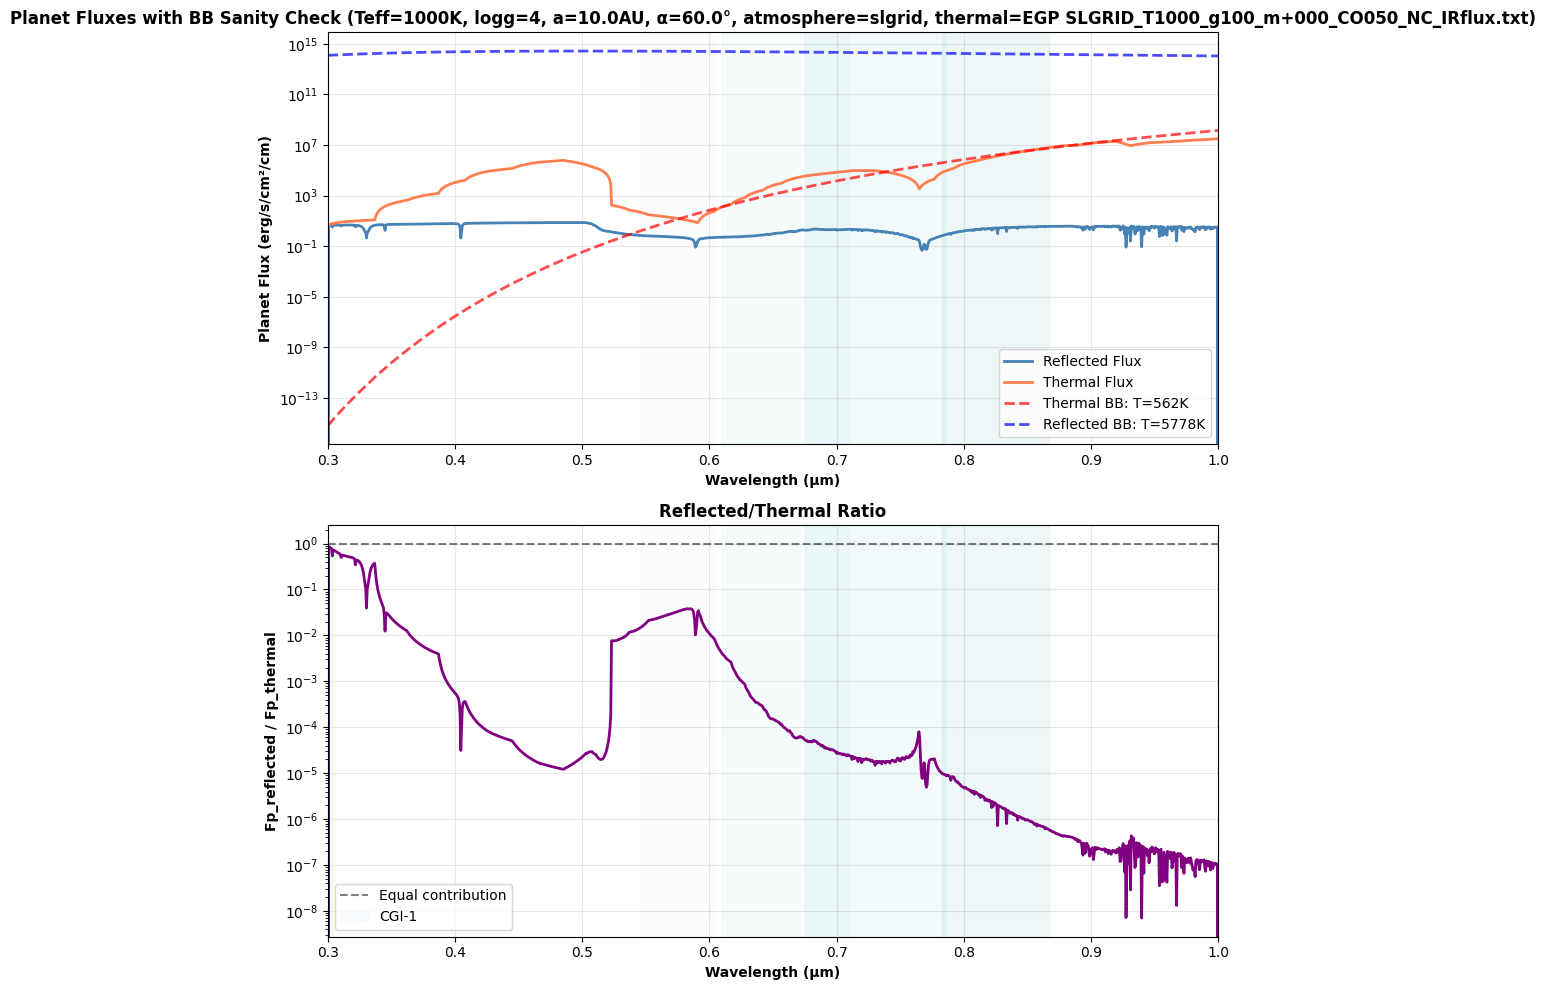

Thermal BB fit: T_eff = 562 K (input: 1000 K), scale = 1.53e+04
Reflected BB fit: T_eff = 5778 K (stellar: 5778.0 K), scale = 1.00e+00


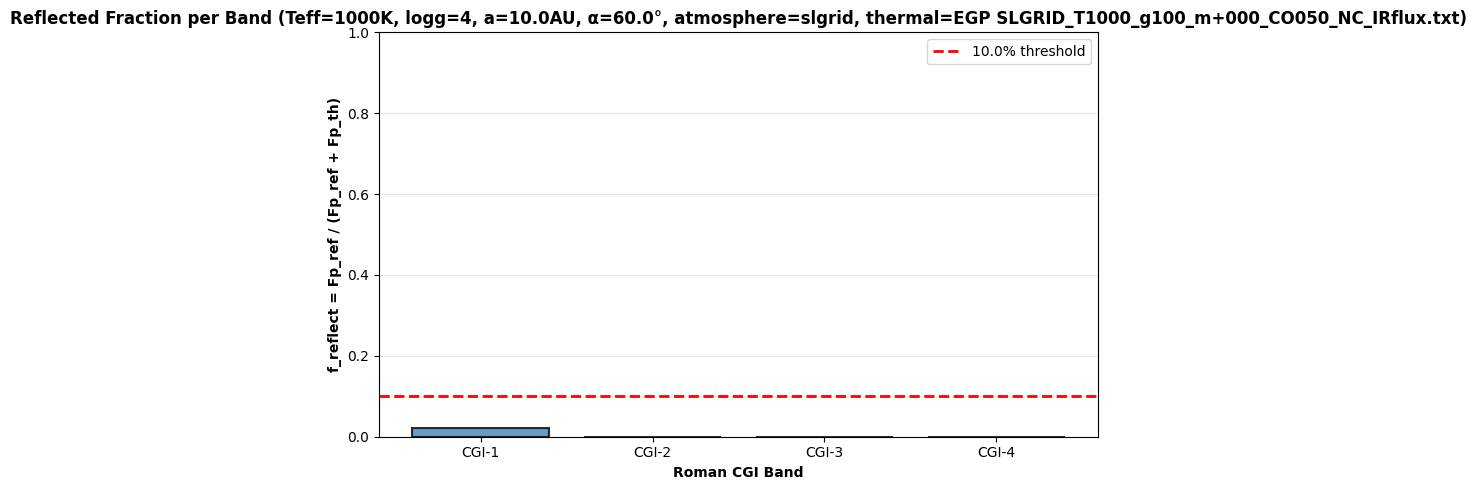

,T_eff,logg,R_p_Rj,a_AU,phase_deg,band,f_reflect,Fp_ref_band,Fp_th_band,decision
0,1000,4,1.0,10.0,60.0,CGI-1,0.020985,0.028640,1.336121,False
1,1000,4,1.0,10.0,60.0,CGI-2,0.000051,0.131094,2571.626262,False
2,1000,4,1.0,10.0,60.0,CGI-3,0.000024,0.148043,6161.160316,False
3,1000,4,1.0,10.0,60.0,CGI-4,0.000001,0.203152,156250.326126,False


In [4]:
RUN_VALIDATION_CASE = True

if RUN_VALIDATION_CASE and HAVE_PICASO:
    case_a = SystemParams(teff_k=1000, logg_cgs=4, rj=1.0, a_au=10.0, phase_deg=PHASE_DEG[0])
    print('=== VALIDATION CASE ===')
    print(
        f'Teff=1000K, logg=4, Rp=1.0 Rj, a=10 AU, '
        f'alpha={PHASE_DEG[0]:g} deg, thermal=EGP g100, bands={SELECTED_BAND_NAMES}'
    )
    df_case = evaluate_hybrid_case(
        case_a,
        thermal_gravity_code=EGP_GRAVITY_CODE,
        lam_grid_um=RUN_LAM_GRID,
        selected_bands=SELECTED_BAND_NAMES,
        do_plots=True,
    )
    display(df_case)
else:
    print('Validation case skipped. Set RUN_VALIDATION_CASE = True to execute it.')


---
## Full Hybrid Grid Run

This runs the RoadRunner reflected-light grid at 60° phase, while the thermal contribution comes from the EGP `g100` files.

By default, the notebook loads the existing local PICASO4-compatible CSV from `roadrunner_egp/results/`. Set `LOAD_EXISTING_CSV = False` to recompute it.


In [5]:
OUTPUT_STEM = 'roadrunner_egp_g100_phase60_grid'
OUTPUT_CSV = RESULTS_DIR / (
    f'{OUTPUT_STEM}.csv'
    if OUTPUT_BAND_TAG == 'all'
    else f'{OUTPUT_STEM}_{OUTPUT_BAND_TAG}.csv'
)
LOAD_EXISTING_CSV = True
RUN_FULL_GRID = True
MAX_WORKERS = 4 #for my mac suggested 2

expected_phases = sorted(float(value) for value in PHASE_DEG)
expected_bands = SELECTED_BAND_NAMES

if LOAD_EXISTING_CSV and OUTPUT_CSV.exists():
    df_all = pd.read_csv(OUTPUT_CSV)
    loaded_phases = sorted(float(value) for value in df_all['phase_deg'].dropna().unique())
    loaded_bands = [band for band in CGI_BANDS if band in set(df_all['band'].dropna())]
    if loaded_phases != expected_phases:
        raise ValueError(f'{OUTPUT_CSV.name} contains phase values {loaded_phases}, expected {expected_phases}.')
    if loaded_bands != expected_bands:
        raise ValueError(f'{OUTPUT_CSV.name} contains bands {loaded_bands}, expected {expected_bands}.')
    print(f'Loaded existing hybrid grid: {OUTPUT_CSV} ({len(df_all)} rows)')
elif RUN_FULL_GRID and HAVE_PICASO:
    total_cases = (len(GRID_TEFFS_K) * len(LOGGS_CGS) * len(R_PLANETS_Rj)
                   * len(SEMI_MAJOR_AU) * len(PHASE_DEG))
    expected_rows = total_cases * len(SELECTED_BAND_NAMES)
    print(f'Running hybrid full grid across temperatures: {GRID_TEFFS_K}')
    print(f'Phase angle(s): {PHASE_DEG}')
    print(f'Selected CGI bands: {SELECTED_BAND_NAMES}')
    print(f'Run wavelength grid: {RUN_LAM_GRID.min():.3f}-{RUN_LAM_GRID.max():.3f} um ({len(RUN_LAM_GRID)} pts)')
    print(f'Total reflected-light cases: {total_cases}')
    print(f'Expected output rows: {expected_rows}')
    print(f'Thermal source: EGP g{EGP_GRAVITY_CODE}')
    print(f'Max workers: {MAX_WORKERS}')

    df_all = run_hybrid_grid_parallel(
        teffs=GRID_TEFFS_K,
        phases=PHASE_DEG,
        lam_grid_um=RUN_LAM_GRID,
        thresh=REFLECT_THRESHOLD,
        thermal_gravity_code=EGP_GRAVITY_CODE,
        max_workers=MAX_WORKERS,
        selected_bands=SELECTED_BAND_NAMES,
    )

    run_phases = sorted(float(value) for value in df_all['phase_deg'].dropna().unique())
    run_bands = [band for band in CGI_BANDS if band in set(df_all['band'].dropna())]
    if run_phases != expected_phases:
        raise RuntimeError(f'Grid produced phase values {run_phases}, expected {expected_phases}.')
    if run_bands != expected_bands:
        raise RuntimeError(f'Grid produced bands {run_bands}, expected {expected_bands}.')

    df_all.to_csv(OUTPUT_CSV, index=False)
    print(f'Saved {len(df_all)} rows -> {OUTPUT_CSV}')
    print(f'  Phase values in results: {run_phases}')
    print(f'  Bands in results: {run_bands}')
    print(f'  Reflection matters: {df_all["decision"].sum()}/{len(df_all)}')
else:
    print('No hybrid grid loaded. Set RUN_FULL_GRID = True or keep LOAD_EXISTING_CSV = True when the CSV exists.')


Running hybrid full grid across temperatures: [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800]
Phase angle(s): [60.0]
Selected CGI bands: ['CGI-1', 'CGI-2', 'CGI-3', 'CGI-4']
Run wavelength grid: 0.300-1.000 um (1200 pts)
Total reflected-light cases: 252
Expected output rows: 1008
Thermal source: EGP g100
Max workers: 4


Running egp grid:   0%|          | 0/252 [00:00<?, ?it/s]

Saved 1008 rows -> /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/results/roadrunner_egp_g100_phase60_grid.csv
  Phase values in results: [60.0]
  Bands in results: ['CGI-1', 'CGI-2', 'CGI-3', 'CGI-4']
  Reflection matters: 68/1008


---
## Summary Analysis and Visualizations

Same summary plots as the original notebook, but now based on the PICASO4-local hybrid reflected-plus-EGP-thermal grid.


=== SUMMARY ===
Bands in results: ['CGI-1', 'CGI-2', 'CGI-3', 'CGI-4']


,sum,count,percent
band,,,
CGI-1,68,252,26.984127
CGI-2,0,252,0.000000
CGI-3,0,252,0.000000
CGI-4,0,252,0.000000



By Teff:


,sum,count,percent
T_eff,,,
500,18,72,25.000000
600,15,72,20.833333
700,13,72,18.055556
800,12,72,16.666667
900,7,72,9.722222
1000,3,72,4.166667
1100,0,72,0.000000
1200,0,72,0.000000
1300,0,72,0.000000


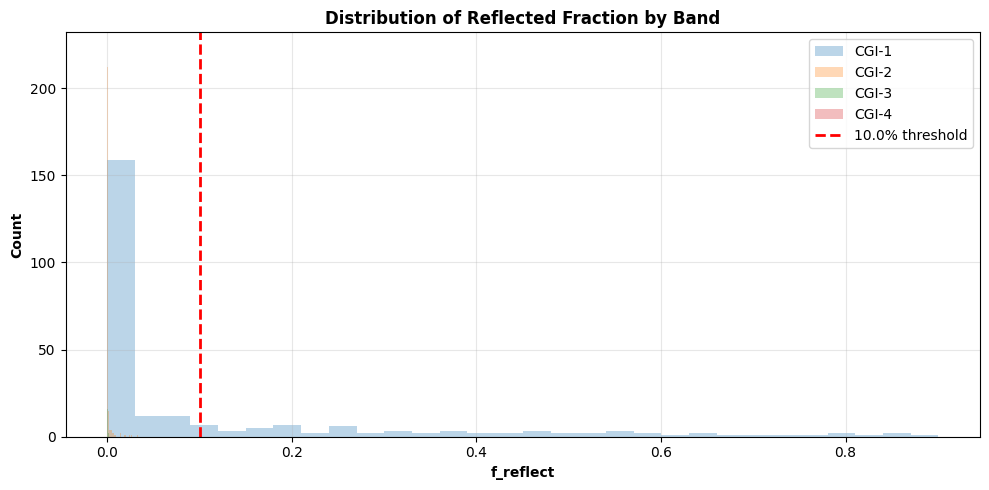

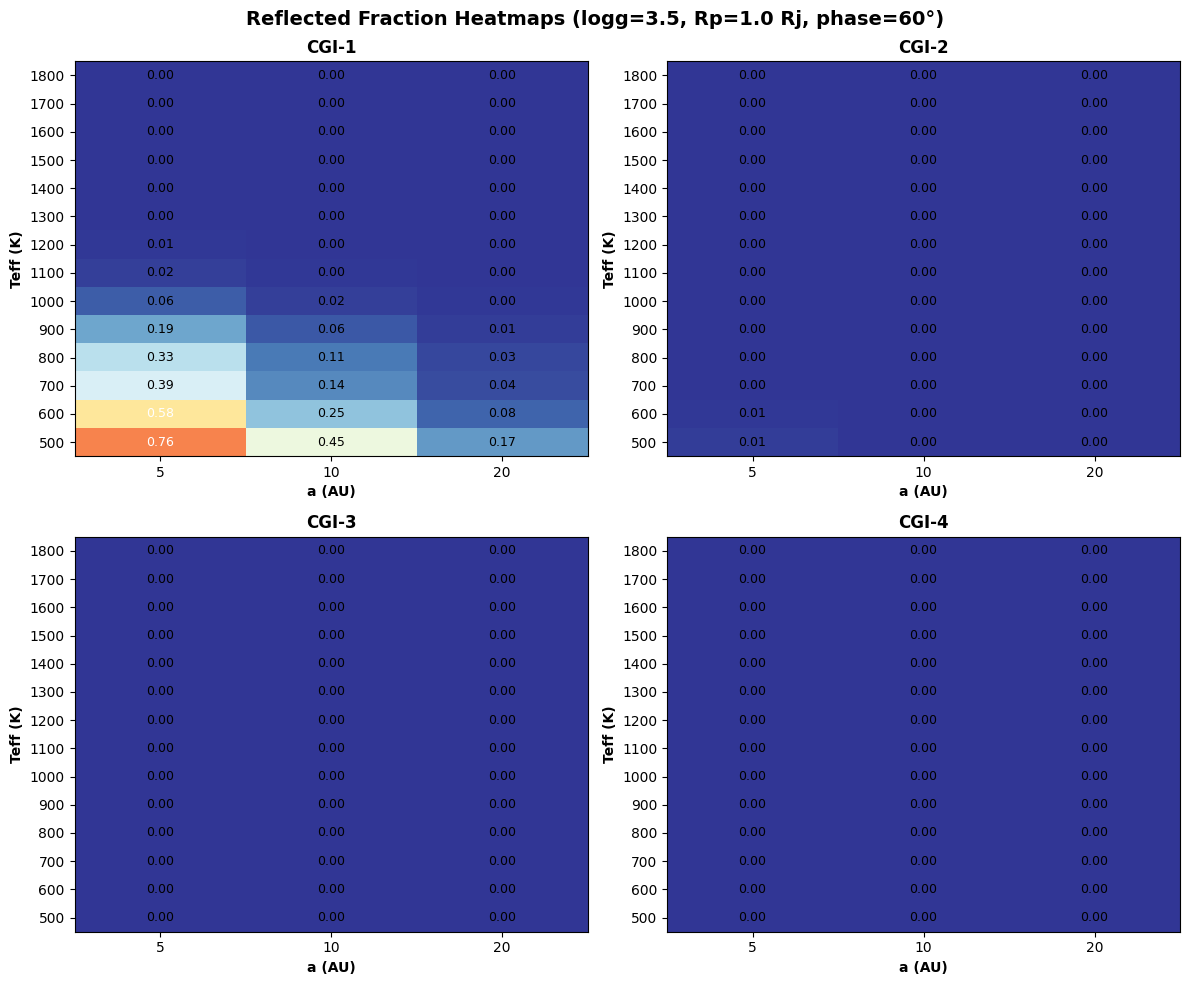

In [6]:
if 'df_all' in dir() and not df_all.empty:
    print('=== SUMMARY ===')
    observed_bands = [band for band in CGI_BANDS if band in set(df_all['band'].dropna())]
    print('Bands in results:', observed_bands)
    summary = df_all.groupby('band')['decision'].agg(['sum', 'count'])
    summary['percent'] = 100 * summary['sum'] / summary['count']
    display(summary)

    print()
    print('By Teff:')
    teff_summary = df_all.groupby('T_eff')['decision'].agg(['sum', 'count'])
    teff_summary['percent'] = 100 * teff_summary['sum'] / teff_summary['count']
    display(teff_summary)

    plot_summary_histogram(df_all)
    plot_summary_heatmaps(df_all)
else:
    print('No hybrid grid results available. Run the grid cell above first.')


---
## Interpretation Notes

- This notebook overrides the shared RoadRunner default phase and runs reflected light at `PHASE_DEG = [60.0]`.
- The `logg`, `R_p_Rj`, and `a_AU` loops still come from the RoadRunner reflected-light grid.
- The thermal contribution is injected from the EGP `g100` file that matches the same temperature.
- Because the thermal source is fixed to `g100`, the hybrid grid isolates how the reflected-light setup changes the 10% threshold result when the thermal spectrum is held to that EGP family.
- The notebook forces all data paths to `aurora/science_inputs` and all PICASO reference paths to `aurora/picaso4_reference`, so it does not depend on the old `timestep` folder at runtime.
